# Emission Calculation

In [1]:
import logging
import os

import astropy.constants as C
import matplotlib.pyplot as plt
import numpy as np
from scipy.differentiate import derivative
from scipy.integrate import fixed_quad, quad
from scipy.interpolate import CubicSpline

logging.basicConfig(format="%(levelname)s: %(asctime)s %(message)s")
logging.getLogger().setLevel(logging.INFO)

%matplotlib widget

# Mission Parameters

In [13]:
R_orbit = C.R_earth.value + 500_000.0  # m
observation_height = 250_000.0  # m, nominal at horizon

pitch_angle = np.acos((C.R_earth.value + observation_height) / R_orbit)
d_view = R_orbit * np.sin(pitch_angle)

aperture = 0.06 * 0.03  # m^2
field_of_view = np.radians(2.35)
pixels = 512

pixel_solid_angle = (
    field_of_view / pixels
) ** 2  # sr, not quite right but close enough

print(f"Pitch angle is {np.degrees(pitch_angle):.1f} deg")
print(f"Nominal viewing distance is {d_view:.0f} m")

Pitch angle is 15.5 deg
Nominal viewing distance is 1837539 m


# Dayglow Emission Model

Text(0, 0.5, 'Volume Emission Rate [m$^{-3}$/s]')

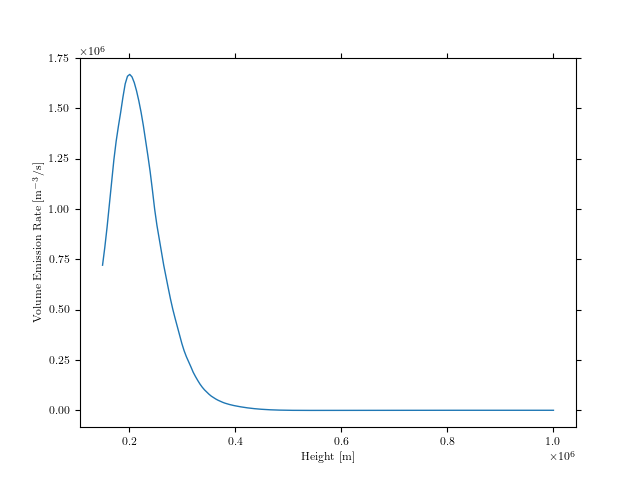

In [14]:
DayglowEmissionModel = np.array(
    [
        [0.0, 1000.0],
        [0.0, 900.0],
        [0.0, 800.0],
        [0.0, 700.0],
        [0.0, 600.0],
        [0.0, 500.0],
        [2.84161, 399.17853],
        [3.13098, 395.07119],
        [3.52790, 390.14239],
        [3.88716, 386.30887],
        [4.31508, 381.92771],
        [4.86211, 377.27273],
        [5.64443, 371.79628],
        [6.40760, 366.86747],
        [7.21990, 362.48631],
        [8.07472, 358.37897],
        [9.58609, 352.08105],
        [10.88221, 347.97371],
        [12.44607, 343.04491],
        [14.44865, 337.84228],
        [17.15305, 332.09200],
        [19.91297, 327.16320],
        [24.53855, 319.76999],
        [28.70010, 314.56736],
        [32.82454, 308.81709],
        [38.96842, 301.97152],
        [43.90850, 297.59036],
        [52.51730, 290.74480],
        [59.61808, 284.99452],
        [69.72885, 277.87514],
        [80.94823, 271.02957],
        [92.58117, 264.18401],
        [106.67871, 257.06462],
        [121.10257, 249.94524],
        [143.76971, 241.73056],
        [160.79165, 234.61117],
        [182.53203, 224.47974],
        [196.66927, 215.99124],
        [208.76343, 204.21687],
        [204.14333, 192.99014],
        [186.66303, 184.50164],
        [170.67952, 176.83461],
        [141.64065, 166.70318],
        [122.00934, 160.95290],
        [105.09892, 155.47645],
        [91.89311, 150.54765],
    ]
)  # emission in cm^-3 s^-1, altitude in km
DayglowEmission = CubicSpline(
    np.flip(DayglowEmissionModel[:, 1]) * 1000,
    np.flip(DayglowEmissionModel[:, 0] * 100**3 / 4 / np.pi / 10),
)  # emission in m^-3 s^-1 sr^-1 as a function of altitude in m

fig, ax = plt.subplots()
h = np.linspace(150_000, 1_000_000, num=200)
ax.plot(h, DayglowEmission(h))
ax.set_xlabel("Height [m]")
ax.set_ylabel(r"Volume Emission Rate [m$^{-3}$/s]")

Text(0, 0.5, 'Volume Emission Rate [m$^{-3}$/s]')

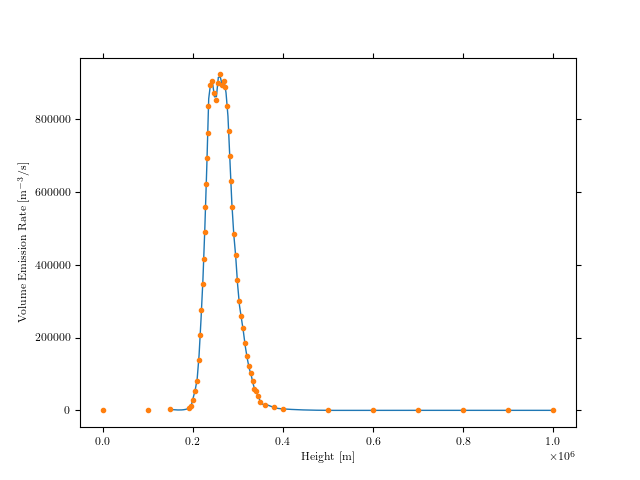

In [15]:
NightglowEmissionData = np.array(
    [
        [0, 0],
        [0, 100],
        [0.03, 150],
        [0.07256894049346663, 191.97898423817867],
        [0.1451378809869368, 196.07705779334503],
        [0.362844702467342, 199.85989492119091],
        [0.6531204644412192, 204.58844133099825],
        [1.0159651669085612, 209.31698774080564],
        [1.7416545718432506, 213.41506129597198],
        [2.612481857764875, 216.56742556917692],
        [3.4833091436864994, 219.40455341506132],
        [4.354136429608127, 221.92644483362523],
        [5.224963715529752, 225.07880910683014],
        [6.168359941944848, 226.6549912434326],
        [7.039187227866472, 228.23117338003505],
        [7.837445573294628, 230.122591943958],
        [8.708272859216253, 231.69877408056044],
        [9.57910014513788, 233.2749562171629],
        [10.522496371552974, 234.85113835376535],
        [11.248185776487661, 238.63397548161123],
        [11.393323657474602, 242.4168126094571],
        [10.957910014513788, 247.14535901926448],
        [10.740203193033379, 251.55866900175135],
        [11.32075471698113, 255.34150612959724],
        [11.611030478955007, 259.7548161120841],
        [11.248185776487661, 264.79859894921196],
        [11.393323657474602, 268.58143607705784],
        [11.175616835994193, 272.3642732049037],
        [10.522496371552974, 276.4623467600701],
        [9.65166908563135, 279.9299474605955],
        [8.780841799709725, 282.13660245183894],
        [7.910014513788097, 284.3432574430824],
        [7.039187227866472, 287.18038528896676],
        [6.095791001451376, 290.96322241681264],
        [5.3701015965166885, 295.061295971979],
        [4.499274310595064, 298.84413309982494],
        [3.7735849056603765, 302.62697022767077],
        [3.265602322206094, 307.0402802101577],
        [2.83018867924528, 311.4535901926445],
        [2.322206095790998, 315.5516637478109],
        [1.8867924528301874, 319.9649737302978],
        [1.5239477503628436, 324.06304728546417],
        [1.3062409288824384, 328.16112084063053],
        [1.0159651669085612, 332.5744308231174],
        [0.7256894049346858, 336.9877408056043],
        [0.6531204644412192, 339.5096322241682],
        [0.5, 345],
        [0.3, 350],
        [0.2, 360],
        [0.1, 380],
        [0.05, 400],
        [0, 500],
        [0, 600],
        [0, 700],
        [0, 800],
        [0, 900],
        [0, 1000],
    ]
)  # emission in cm^-3 s^-1, altitude in km
NightglowEmission = CubicSpline(
    NightglowEmissionData[:, 1] * 1000,
    NightglowEmissionData[:, 0] * 100**3 / 4 / np.pi,
)  # emission in m^-3 s^-1 sr^-1 as a function of altitude in m

fig, ax = plt.subplots()
h = np.linspace(150_000, 1_000_000, num=200)
ax.plot(h, NightglowEmission(h))
ax.plot(
    NightglowEmissionData[:, 1] * 1000,
    NightglowEmissionData[:, 0] * 100**3 / 4 / np.pi,
    ".",
)
ax.set_xlabel("Height [m]")
ax.set_ylabel(r"Volume Emission Rate [m$^{-3}$/s]")

# Height as a function of distance

In [16]:
def height(distance, pitch_angle):
    return np.minimum(
        np.sqrt(R_orbit**2 + distance**2 - 2 * R_orbit * distance * np.sin(pitch_angle))
        - C.R_earth.value,
        1_000_000.0,
    )

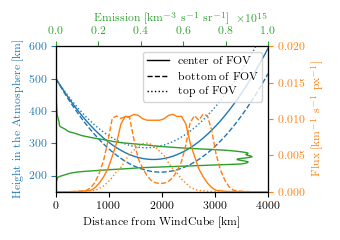

In [21]:
fig, ax = plt.subplots(figsize=(3.4, 2.4))
ax.tick_params(axis="y", colors="tab:blue")

secax = ax.twiny()
secax.xaxis.label.set_color("tab:green")
secax.tick_params(axis="x", colors="tab:green")
secax.plot(
    NightglowEmission(np.linspace(150, 600, num=200) * 1000) * 1000**3,
    np.linspace(150, 600, num=200),
    c="tab:green",
)

ax.plot(
    np.linspace(0, 4_000),
    height(np.linspace(0, 4_000_000), pitch_angle) / 1000,
    "-",
    c="tab:blue",
)
ax.plot(
    np.linspace(0, 4_000),
    height(np.linspace(0, 4_000_000), pitch_angle + field_of_view / 2) / 1000,
    "--",
    c="tab:blue",
)
ax.plot(
    np.linspace(0, 4_000),
    height(np.linspace(0, 4_000_000), pitch_angle - field_of_view / 2) / 1000,
    ":",
    c="tab:blue",
)

thrdax = ax.twinx()
thrdax.xaxis.label.set_color("tab:orange")
thrdax.tick_params(axis="y", colors="tab:orange")
thrdax.plot(
    np.linspace(0, 4_000),
    NightglowEmission(height(np.linspace(0, 4_000_000), pitch_angle))
    * 1000
    * aperture
    * pixel_solid_angle,
    "-",
    c="tab:orange",
    label="center of FOV",
)
thrdax.plot(
    np.linspace(0, 4_000),
    NightglowEmission(
        height(np.linspace(0, 4_000_000), pitch_angle + field_of_view / 2)
    )
    * 1000
    * aperture
    * pixel_solid_angle,
    "--",
    c="tab:orange",
    label="bottom of FOV",
)
thrdax.plot(
    np.linspace(0, 4_000),
    NightglowEmission(
        height(np.linspace(0, 4_000_000), pitch_angle - field_of_view / 2)
    )
    * 1000
    * aperture
    * pixel_solid_angle,
    ":",
    c="tab:orange",
    label="top of FOV",
)
ax.set_xlim(0, 4e3)
ax.set_ylim(1.5e2, 6e2)

ax.set_xlabel("Distance from WindCube [km]")
ax.set_ylabel("Height in the Atmosphere [km]", c="tab:blue")

secax.set_xlim(0, 1.0e15)
secax.set_xlabel("Emission [km$^{-3}$ s$^{-1}$ sr$^{-1}$]", c="tab:green")

thrdax.set_ylim(0, 0.02)
thrdax.set_ylabel("Flux [km$^{-1}$ s$^{-1}$ px$^{-1}$]", c="tab:orange")

for handle in thrdax.legend().legend_handles:
    handle.set_color('black')

fig.tight_layout()

fig.savefig("photon_flux.pdf")

In [22]:
pitch_angles = (np.arange(pixels) / pixels - 0.5) * field_of_view + pitch_angle

photon_flux = np.array(
    [
        quad(
            lambda d: NightglowEmission(height(d, pa)) * aperture * pixel_solid_angle,
            0,
            5_000_000,
            limit=1000,
        )[0]
        for pa in pitch_angles
    ]
)

/var/folders/jq/rw090dv91w1fqss7lp8rdmbc6z3h14/T/ipykernel_67565/504096734.py:5: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  quad(


Text(0, 0.5, 'Y pixel')

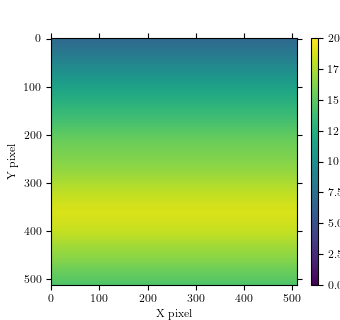

In [24]:
fig, ax = plt.subplots(figsize=(3.4, 3.2))

im = ax.imshow(np.transpose(np.tile(photon_flux, [pixels, 1])), vmin=0, vmax=20)

cax = fig.add_axes(
    [ax.get_position().x1 + 0.04, ax.get_position().y0, 0.02, ax.get_position().height]
)
fig.colorbar(
    im,
    label=r"Photon Flux [s$^{-1}$]",
    cax=cax,
)

ax.set_xlabel("X pixel")
ax.set_ylabel("Y pixel")

In [25]:
np.save("photon_flux.npy", np.transpose(np.tile(photon_flux, [pixels, 1])))

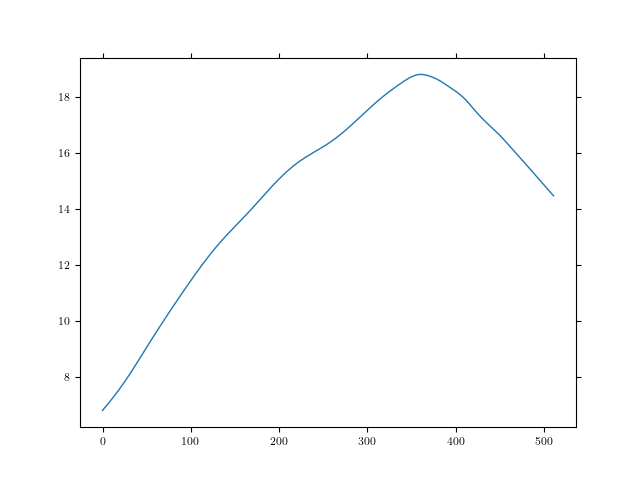

In [26]:
fig, ax = plt.subplots()
ax.plot(np.arange(pixels), photon_flux)